## Decision Tree Model

In this section, we implement the Decision Tree classifier as a baseline model for phishing website detection. 

We evaluate the model using both Gini and Entropy criteria and compare their performance using metrics such as accuracy, precision, recall, F1 score, and confusion matrix. The goal is to identify which splitting criterion provides better performance for this dataset.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [9]:
# Load Clean Dataset
df = pd.read_csv("../../data/processed-phishing.csv")

In [10]:
# Separate features and target variable
X = df.drop("Result", axis=1)
y = df["Result"]

print(X.shape)
print(y.shape)

(5849, 30)
(5849,)


In [11]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
# Create the Decision Tree Classifier (Gini)
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train, y_train)

# Make predictions
y_pred = dt.predict(X_test)

In [24]:
# Evaluate the Gini model
print("Decision Tree (Gini) Results:")
print()
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Decision Tree (Gini) Results:

Accuracy: 0.917094017094017
Precision: 0.9180035650623886
Recall: 0.9098939929328622
F1 Score: 0.9139307897071872

Confusion Matrix:
[[558  46]
 [ 51 515]]


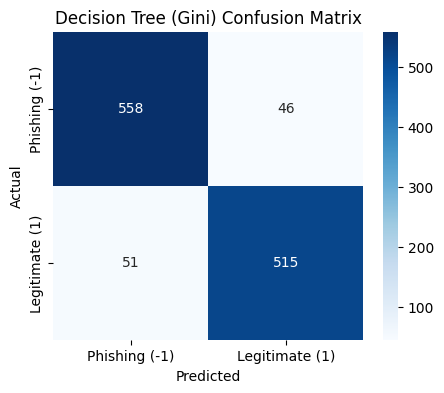

In [22]:
# Gini Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Phishing (-1)", "Legitimate (1)"],
            yticklabels=["Phishing (-1)", "Legitimate (1)"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree (Gini) Confusion Matrix")

plt.show()

### Decision Tree (Gini) Results Analysis

The Decision Tree Gini model achieved strong performance on the phishing detection task.

- The model achieved an accuracy of approximately 91.7%, indicating that it correctly classified the majority of websites.
- The precision score (~0.918) shows that when the model predicts a website as phishing, it is correct most of the time.
- The recall score (~0.910) indicates that the model successfully identifies a high proportion of actual phishing websites.
- The F1 score (~0.914) reflects a good balance between precision and recall.

From the confusion matrix:
- 558 phishing websites were correctly classified.
- 515 legitimate websites were correctly classified.
- 46 phishing websites were misclassified as legitimate.
- 51 legitimate websites were misclassified as phishing.

Overall, the Decision Tree performs well as a baseline model, with relatively low misclassification rates and balanced performance across both classes.

In [25]:
# Create the Decision Tree Classifier (Entropy)

dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)

# Train the model
dt_entropy.fit(X_train, y_train)

# Make predictions
y_pred_entropy = dt_entropy.predict(X_test)


In [ ]:
# Evaluate the Entropy model
print("Decision Tree (Entropy) Results:")

print("Accuracy:", accuracy_score(y_test, y_pred_entropy))
print("Precision:", precision_score(y_test, y_pred_entropy))
print("Recall:", recall_score(y_test, y_pred_entropy))
print("F1 Score:", f1_score(y_test, y_pred_entropy))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_entropy))

Decision Tree (Entropy) Results:
Accuracy: 0.9247863247863248
Precision: 0.9314079422382672
Recall: 0.911660777385159
F1 Score: 0.9214285714285714
Confusion Matrix:
[[566  38]
 [ 50 516]]


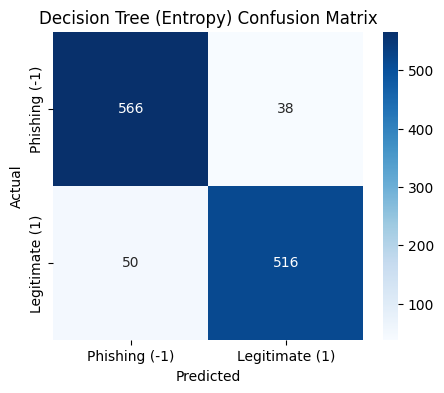

In [27]:
# Entropy Confusion Matrix Visualization
cm_entropy = confusion_matrix(y_test, y_pred_entropy)

plt.figure(figsize=(5,4))
sns.heatmap(cm_entropy, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Phishing (-1)", "Legitimate (1)"],
            yticklabels=["Phishing (-1)", "Legitimate (1)"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree (Entropy) Confusion Matrix")

plt.show()

### Decision Tree (Entropy) Results Analysis

The Decision Tree model using the entropy criterion shows strong performance and slightly improves upon the Gini-based model.

- The model achieved an accuracy of approximately 92.5%, which is higher than the Gini-based model.
- The precision score (~0.931) indicates that the model is highly accurate when predicting phishing websites.
- The recall (~0.912) shows that the model successfully identifies a large proportion of phishing cases.
- The F1 score (~0.921) reflects a strong balance between precision and recall.

From the confusion matrix:
- 566 phishing websites were correctly classified.
- 516 legitimate websites were correctly classified.
- 38 phishing websites were misclassified as legitimate.
- 50 legitimate websites were misclassified as phishing.

Overall, the entropy-based Decision Tree performs slightly better than the Gini-based model, suggesting that information gain provides a marginal improvement for this dataset.

Based on the comparison between Gini and Entropy criteria, the entropy-based Decision Tree is selected as the final baseline model. 

Although both approaches produced similar results, the entropy model achieved slightly higher accuracy, precision, recall, and F1 score. Therefore, entropy provides a marginal improvement and is better suited for this dataset.

In [31]:
# Check for overfitting (Entropy model)

y_train_pred = dt_entropy.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred_entropy))

Train Accuracy: 0.9908100021372088
Test Accuracy: 0.9247863247863248


In [28]:
# Tree Depth
print("Entropy Tree Depth:", dt_entropy.get_depth())
print("Entropy Number of Leaves:", dt_entropy.get_n_leaves())

Entropy Tree Depth: 24
Entropy Number of Leaves: 404


### Decision Tree Complexity Analysis

The entropy-based Decision Tree has a depth of 24 and 404 leaf nodes, indicating a highly complex model. 

The model achieves a training accuracy of approximately 99.1% and a test accuracy of approximately 92.5%, suggesting a moderate degree of overfitting. The high training accuracy indicates that the model is capturing detailed patterns in the training data, while the drop in test accuracy shows reduced generalization to unseen data.

However, despite this complexity, the model still performs well on the test set, indicating that it maintains reasonable generalization. This reflects a trade-off between model complexity and performance, which can be further improved using ensemble methods in later stages.

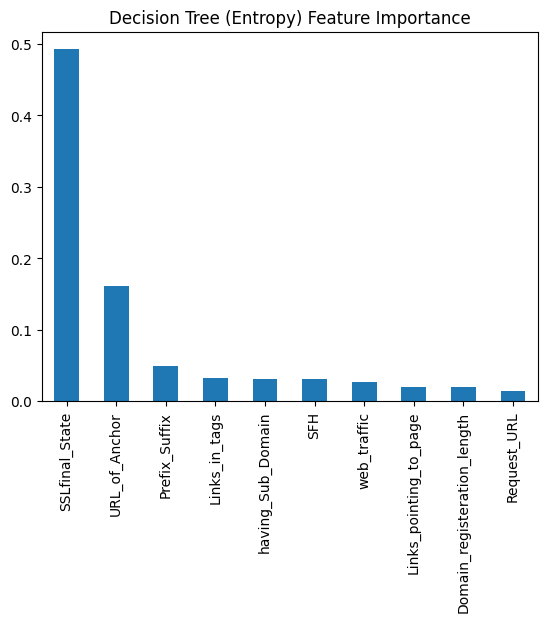

In [30]:
import matplotlib.pyplot as plt

feat_importance = pd.Series(dt_entropy.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False)

feat_importance.head(10).plot(kind='bar')
plt.title("Decision Tree (Entropy) Feature Importance")
plt.show()

### Top 10 Important Features (Decision Tree)

The following features were identified as the most important based on the Decision Tree model:

1. SSLfinal_State  
2. URL_of_Anchor  
3. Prefix_Suffix  
4. Links_in_tags  
5. having_Sub_Domain  
6. SFH  
7. web_traffic  
8. Links_pointing_to_page
9. Domain_registeration_length
10. Request_URL  

## Decision Tree Summary

The Decision Tree model demonstrates strong performance as a baseline classifier for phishing detection. Both Gini and Entropy criteria produced similar results; however, the entropy-based model achieved slightly better performance across all evaluation metrics and was selected as the final model.

The model achieved high accuracy and balanced precision and recall, indicating effective classification of both phishing and legitimate websites. The entropy-based model achieved a test accuracy of approximately 92.5%.

The model shows a moderate degree of overfitting, as indicated by the high training accuracy (~99.1%) compared to the test accuracy. This is expected due to the high complexity of the tree. However, despite this, the model still generalizes reasonably well to unseen data.

Overall, the Decision Tree provides a strong baseline, which can be further improved using ensemble methods such as Random Forest and XGBoost.